# Lennard-Jones vs. spring potential

## a) Plot the LJ and spring potential
I use σ = ε = 1. The minimum of LJ is at r0 = 2^(1/6) σ with v(r0) = -ε.
For the spring I use v = 1/2 k (r - r0)^2 - ε, so the minimum is at the same place and can be compared.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

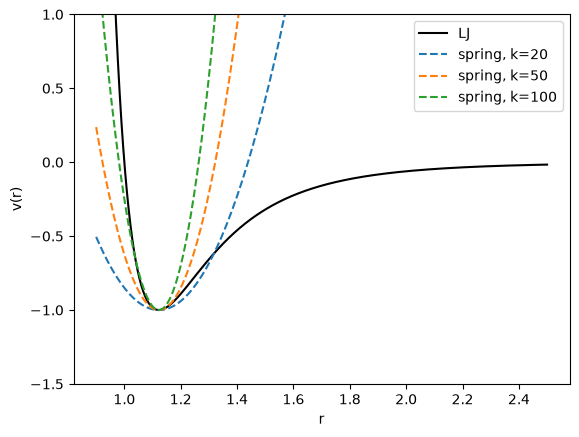

In [2]:
# LJ potential: v(r) = 4*eps*((sigma/r)^12 - (sigma/r)^6)
# Spring potential: v(r) = 1/2*k*(r - r0)^2 - eps, shifted so its minimum is at the LJ minimum
# sigma = eps = 1, r0 = 2^(1/6)
# Spring constants: k = 20, 50, 100
sigma, eps = 1, 1
r0 = 2**(1/6)*sigma
r = np.linspace(0.9, 2.5, 500)

v_lj = 4*eps*((sigma/r)**12 - (sigma/r)**6)

fig, ax = plt.subplots()
ax.plot(r, v_lj, 'k', label='LJ')
for k in [20, 50, 100]:
    ax.plot(r, 0.5*k*(r - r0)**2 - eps, '--', label=f'spring, k={k}')
ax.set_ylim(-1.5, 1)
ax.set_xlabel('r'); ax.set_ylabel('v(r)'); ax.legend()
plt.show()

Both potentials have a minimum. There the force F = -dv/dr is zero, so it is a stable equilibrium.
If a particle is pushed a bit away from the minimum, the force pushes it back, so it oscillates around the minimum.
Close to the minimum the LJ potential looks like a parabola, just like the spring. For k around 50 they almost overlap.
Further away they are different. LJ is very steep for r < r0 and flattens to 0 for large r, so the bond can break. The spring keeps growing.

## b) Small oscillations
For small oscillations I Taylor expand v(r) around r0:

$v(r) \approx v(r_0) + v'(r_0)(r - r_0) + \frac{1}{2} v''(r_0)(r - r_0)^2$

At the minimum v(r0) = -ε and v'(r0) = 0. The second derivative is

$v''(r) = 4\varepsilon\left(\frac{156\sigma^{12}}{r^{14}} - \frac{42\sigma^6}{r^8}\right)$

At r0 we have (σ/r0)^6 = 1/2 and (σ/r0)^12 = 1/4, so

$v''(r_0) = \frac{4\varepsilon}{r_0^2}(39 - 21) = \frac{72\varepsilon}{r_0^2} = \frac{72\varepsilon}{2^{1/3}\sigma^2}$

So for small oscillations:

$v(r) \approx -\varepsilon + \frac{36\varepsilon}{2^{1/3}\sigma^2}(r - r_0)^2$

## c) Spring constant
A harmonic oscillator has v = 1/2 k x^2. Comparing with b), with x = r - r0:

$k = v''(r_0) = \frac{72\varepsilon}{2^{1/3}\sigma^2} \approx 57.1\,\frac{\varepsilon}{\sigma^2}$

This matches the plot in a), where k = 50 was already close.

## d) Two bonded masses
As in the picture, m1 moves r1 to the right and m2 moves r2 to the left. The spring is then compressed by r1 + r2, and it pushes both masses back:

$m_1 \ddot{r}_1 = -k(r_1 + r_2)$

$m_2 \ddot{r}_2 = -k(r_1 + r_2)$

Dividing by the masses and adding the two equations:

$\ddot{r}_1 + \ddot{r}_2 = -k\left(\frac{1}{m_1} + \frac{1}{m_2}\right)(r_1 + r_2)$

With x = r1 + r2 and the reduced mass μ = m1 m2/(m1 + m2), this is a harmonic oscillator:

$\ddot{x} = -\frac{k}{\mu}x$

So the particles oscillate with

$\omega = \sqrt{\frac{k}{\mu}}, \qquad f = \frac{1}{2\pi}\sqrt{\frac{k}{\mu}}$

With the LJ spring constant from c):

$\omega = \sqrt{\frac{72\varepsilon}{2^{1/3}\sigma^2\mu}}$